In [ ]:
import pandas as pd
import re
import os
from pathlib import Path
import sys
import numpy as np
from tqdm import tqdm
import time
import matplotlib.pyplot as plt

from deeplc import DeepLC
from psm_utils.psm import PSM
from psm_utils.psm_list import PSMList

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from pyteomics import mgf, mass
from make_predictions.intensity_predictions import (
    obtain_predictions_pairs,
    safe_obtain_rt_predictions,
    safe_obtain_ccs_predictions,
)
from seq_utils.peptide import switch_random_il, get_proforma_bracketed
import metrics.metrics as M

from deeplc import DeepLC
from psm_utils.psm import PSM
from psm_utils.psm_list import PSMList
from seq_utils.peptide import has_il_outside_brackets

import seaborn as sns
from seq_utils.peptide import has_il_outside_brackets

%matplotlib inline

In [2]:
# Load MaxQuant search results (same filtering as retention_time_il_swap.ipynb)
df = pd.read_csv("../temp_data/input_file.txt", sep="\t")
df = df[df["Sequence"].str.len() < 30]

# Parse modifications to ProForma format (for Koina API)
modification_dict_koina = {"(ox)": "UNIMOD:35", "(ac)": "UNIMOD:1", "(oxidation (m))": "UNIMOD:35", "(acetyl (protein n-term))": "UNIMOD:1"}
df["proforma_koina"] = df["Modified sequence"].apply(
    get_proforma_bracketed,
    before_aa=False, isalpha=True, isupper=True,
    pattern="\\([^()]*\\)|\\([^()]*\\([^()]*\\)[^()]*\\)",
    modification_dict=modification_dict_koina,
)

# Parse modifications to ProForma format (for DeepLC - uses modification names)
modification_dict_deeplc = {"(ox)": "Oxidation", "(ac)": "Acetyl", "(oxidation (m))": "Oxidation", "(acetyl (protein n-term))": "Acetyl"}
df["proforma_deeplc"] = df["Modified sequence"].apply(
    get_proforma_bracketed,
    before_aa=False, isalpha=True, isupper=True,
    pattern="\\([^()]*\\)|\\([^()]*\\([^()]*\\)[^()]*\\)",
    modification_dict=modification_dict_deeplc,
)

# Average retention times per unique peptide
merged_df = df.merge(
    df.groupby("proforma_deeplc")["Calibrated retention time"].mean(),
    on="proforma_deeplc", how="left", suffixes=('', '_mean')
)
merged_df = merged_df.drop_duplicates(subset="proforma_deeplc", keep="first")

# For fragment intensity: filter to unmodified, charge 2, with MS/MS scans
df_intensity = df[~df["proforma_koina"].str.contains(r"\[", na=False)].copy()
df_intensity = df_intensity[~np.isnan(df_intensity["MS/MS scan number"])]
df_intensity = df_intensity[df_intensity["Charge"] == 2]

peptides = np.array(df_intensity["proforma_koina"])
charges = np.array(df_intensity["Charge"])
peptides_switched = np.array([switch_random_il(p) for p in peptides])

print(f"Full dataset (for RT): {len(merged_df)} unique peptides")
print(f"Fragment intensity dataset (unmodified, charge 2): {len(df_intensity)} peptides")

C:\Users\robbi\AppData\Local\Temp\ipykernel_129620\1027923504.py:2: DtypeWarning: Columns (50) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../temp_data/input_file.txt", sep="\t")


Full dataset (for RT): 44227 unique peptides
Fragment intensity dataset (unmodified, charge 2): 121526 peptides


In [3]:
# Load MGF files
def parse_mgf(file_path):
    filename = os.path.splitext(os.path.basename(file_path))[0]
    spectra = {}
    with mgf.read(file_path) as reader:
        for spectrum in tqdm(reader):
            scan_str = spectrum.get("params", {})["title"].split(" scan=")[1].replace("\"", "")
            scan_number = int(scan_str) if scan_str else 0
            spectra[scan_number] = {
                'm/z array': spectrum.get('m/z array', []),
                'intensity array': spectrum.get('intensity array', [])
            }
    return {filename: spectra}

files = [
    "../temp_data/LFQ_Orbitrap_DDA_Condition_A_Sample_Alpha_01.mgf",
    "../temp_data/LFQ_Orbitrap_DDA_Condition_A_Sample_Alpha_02.mgf",
    "../temp_data/LFQ_Orbitrap_DDA_Condition_A_Sample_Alpha_03.mgf",
    "../temp_data/LFQ_Orbitrap_DDA_Condition_B_Sample_Alpha_01.mgf",
    "../temp_data/LFQ_Orbitrap_DDA_Condition_B_Sample_Alpha_02.mgf",
    "../temp_data/LFQ_Orbitrap_DDA_Condition_B_Sample_Alpha_03.mgf",
]

mgf_dict = {}
for f in files:
    mgf_dict.update(parse_mgf(f))

100%|██████████| 109507/109507 [00:18<00:00, 5872.82it/s]

100%|██████████| 111413/111413 [00:20<00:00, 5318.94it/s] 

100%|██████████| 117880/117880 [00:15<00:00, 7512.19it/s] 

100%|██████████| 118174/118174 [00:30<00:00, 3929.13it/s]


In [4]:
# Load or generate fragment intensity predictions
peptides_switch_predictions_f = "../temp_data/peptides_switch_predictions_puyvelde.csv"
peptides_predictions_f = "../temp_data/peptides_predictions_puyvelde.csv"

def safe_obtain_predictions(peptides_batch, switched, charges, max_retries=3):
    for attempt in range(max_retries):
        try:
            return obtain_predictions_pairs(peptides_batch, switched=switched, 
                                            model="AlphaPeptDeep_ms2_generic", 
                                            charges=charges, collision_energies=27)
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(1)
            else:
                raise RuntimeError(f"Prediction failed after {max_retries} attempts.") from e

if os.path.exists(peptides_switch_predictions_f) and os.path.exists(peptides_predictions_f):
    peptides_switch_predictions = pd.read_csv(peptides_switch_predictions_f)
    peptides_predictions = pd.read_csv(peptides_predictions_f)
else:
    batch_size = 5000
    peptides_switch_predictions_list, peptides_predictions_list = [], []
    for i in tqdm(range(0, len(peptides), batch_size)):
        batch, batch_switched = peptides[i:i+batch_size], peptides_switched[i:i+batch_size]
        batch_charges = charges[i:i+batch_size]
        peptides_switch_predictions_list.append(safe_obtain_predictions(batch_switched, True, batch_charges))
        peptides_predictions_list.append(safe_obtain_predictions(batch, False, batch_charges))
    
    peptides_switch_predictions = pd.concat(peptides_switch_predictions_list, ignore_index=True)
    peptides_predictions = pd.concat(peptides_predictions_list, ignore_index=True)
    peptides_switch_predictions.to_csv(peptides_switch_predictions_f, index=False)
    peptides_predictions.to_csv(peptides_predictions_f, index=False)

# Create lookup dictionaries
dict_predictions = dict(tuple(peptides_predictions.groupby("peptide_sequences")))
dict_predictions_switched = dict(tuple(peptides_switch_predictions.groupby("peptide_sequences")))

In [5]:
# Spectrum annotation and matching functions
def get_theoretical_fragments(peptide_sequence, max_charge=2):
    clean_seq = re.sub(r'\[.*?\]', '', peptide_sequence)
    fragments = []
    seq_len = len(clean_seq)
    for i in range(1, seq_len):
        for z in range(1, max_charge + 1):
            try:
                fragments.append({'ion': f"b{i}", 'charge': z, 'mz': mass.fast_mass(clean_seq[:i], ion_type='b', charge=z)})
            except: pass
            try:
                fragments.append({'ion': f"y{seq_len-i}", 'charge': z, 'mz': mass.fast_mass(clean_seq[i:], ion_type='y', charge=z)})
            except: pass
    return fragments

def annotate_spectrum(mz_array, intensity_array, peptide_sequence, charge, tol_ppm=20):
    mz_array, intensity_array = np.array(mz_array, dtype=np.float64), np.array(intensity_array, dtype=np.float64)
    matched, used_peaks = [], set()
    for frag in get_theoretical_fragments(peptide_sequence, max_charge=charge):
        mz_diff = np.abs((mz_array - frag['mz']) / frag['mz'] * 1e6)
        matches = np.where(mz_diff < tol_ppm)[0]
        if len(matches) > 0:
            best_idx = matches[np.argmin(mz_diff[matches])]
            if best_idx not in used_peaks:
                used_peaks.add(best_idx)
                matched.append({'ion': frag['ion'], 'charge': frag['charge'], 'intensity': intensity_array[best_idx]})
    return pd.DataFrame(matched)

# Match observed spectra to predictions (using df_intensity)
dict_orig_to_swap = dict(zip(peptides, peptides_switched))
dict_il_intensity = {}
for idx, row in tqdm(df_intensity.iterrows(), total=len(df_intensity), desc="Processing"):
    mz_array = mgf_dict[row["Raw file"]][int(row['MS/MS scan number'])]["m/z array"]
    intensity_array = mgf_dict[row["Raw file"]][int(row['MS/MS scan number'])]['intensity array']
    
    df_annotation = annotate_spectrum(mz_array, intensity_array, row['proforma_koina'], row['Charge'])
    if df_annotation.empty:
        continue

    swap_sequence = dict_orig_to_swap.get(row['proforma_koina'])
    sub_df_pred = dict_predictions.get(row['proforma_koina'])
    sub_df_pred_sw = dict_predictions_switched.get(swap_sequence) if swap_sequence else None
    if sub_df_pred is None or sub_df_pred_sw is None:
        continue

    # Parse prediction annotations
    sub_df_pred = sub_df_pred.copy()
    sub_df_pred_sw = sub_df_pred_sw.copy()
    sub_df_pred[['ion', 'charge']] = sub_df_pred['annotation'].str.extract(r"([a-zA-Z]+\d+)\+(\d+)")
    sub_df_pred['charge'] = sub_df_pred['charge'].astype(int)
    sub_df_pred_sw[['ion', 'charge']] = sub_df_pred_sw['annotation'].str.extract(r"([a-zA-Z]+\d+)\+(\d+)")
    sub_df_pred_sw['charge'] = sub_df_pred_sw['charge'].astype(int)
    df_annotation['charge'] = df_annotation['charge'].astype(int)

    # Merge observed with predictions
    merged = pd.merge(df_annotation, sub_df_pred, on=['ion', 'charge'], how='inner')
    merged_all = pd.merge(merged, sub_df_pred_sw, on=['ion', 'charge'], how='inner').drop_duplicates()
    
    if merged_all.empty or max(merged_all["intensity"].values) == 0:
        continue
        
    max_int = max(merged_all["intensity"].values)
    dict_il_intensity[row['proforma_koina']] = {
        "intensity_obs_norm": merged_all["intensity"].values / max_int,
        "intensities_orig": merged_all["intensities_x"].values,
        "intensities_swapped": merged_all["intensities_y"].values,
        "mz_orig": merged_all["mz_x"].values,
    }

Processing: 100%|██████████| 121526/121526 [08:10<00:00, 248.00it/s]


In [6]:
# Score all peptides with all metrics
metric_keys = [
    "mse", "pearson_correlation", "spearman_correlation", "dot_product",
    "mara_similarity", "modified_dot_product", "massbank_score", "gnps_score",
    "stein_scott_score", "wasserstein", "kendall_tau", "mutual_information",
    "bray_curtis", "canberra_distance", "mara_weighted_similarity", "diagnostic_weighted_similarity",
]

scored_dict_seqs = {}
for seq, frag in tqdm(dict_il_intensity.items()):
    score_dict = {}
    inp_base = {"mz1": frag["mz_orig"], "mz2": frag["mz_orig"], 
                "diagnostic_mz": np.array([]), "mz": max(frag["mz_orig"])}
    
    for key in metric_keys:
        try:
            score = getattr(M, key)(intensity1=frag["intensity_obs_norm"], intensity2=frag["intensities_orig"], **inp_base)
        except: score = np.nan
        try:
            score_sw = getattr(M, key)(intensity1=frag["intensity_obs_norm"], intensity2=frag["intensities_swapped"], **inp_base)
        except: score_sw = np.nan
        score_dict[f"{key}|orig"], score_dict[f"{key}|swapped"] = score, score_sw
    
    scored_dict_seqs[seq] = score_dict

scored_df_seqs = pd.DataFrame(scored_dict_seqs).T

  0%|          | 0/30611 [00:00<?, ?it/s]c:\Users\robbi\OneDrive\Documents\GitHub\spectral_similarity\metrics\metrics.py:24: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(intensity1, intensity2)
c:\Users\robbi\OneDrive\Documents\GitHub\spectral_similarity\metrics\metrics.py:30: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(intensity1, intensity2)
  0%|          | 40/30611 [00:00<01:22, 372.10it/s]c:\Users\robbi\OneDrive\Documents\GitHub\spectral_similarity\metrics\metrics.py:24: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(intensity1, intensity2)
c:\Users\robbi\OneDrive\Documents\GitHub\spectral_similarity\metrics\metrics.py:30: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(intensity1, intensity2)
  9%|▉        

In [ ]:
# Train/eval split (10% for calibration, 90% for evaluation)
df_train = merged_df.sample(frac=0.1, random_state=42)
df_eval = merged_df.drop(df_train.index)

# Build PSM lists
psm_list_train = PSMList(psm_list=[
    PSM(peptidoform=row["proforma_deeplc"], retention_time=row["Calibrated retention time_mean"], spectrum_id=idx)
    for idx, row in df_train.iterrows()
])
psm_list_eval = PSMList(psm_list=[
    PSM(peptidoform=row["proforma_deeplc"], retention_time=row["Calibrated retention time_mean"], spectrum_id=idx)
    for idx, row in df_eval.iterrows()
])
psm_list_eval_swapped = PSMList(psm_list=[
    PSM(peptidoform=switch_random_il(row["proforma_deeplc"]), retention_time=row["Calibrated retention time_mean"], spectrum_id=idx)
    for idx, row in df_eval.iterrows()
])

# Train DeepLC and make predictions
dlc = DeepLC(deeplc_retrain=False, n_epochs=20)
dlc.calibrate_preds(psm_list_train)
preds = dlc.make_preds(psm_list=psm_list_eval)
preds_swapped = dlc.make_preds(psm_list=psm_list_eval_swapped)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step
 1/39 ━━━━━━━━━━━━━━━━━━━━ 7s 209ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001CCD1C0A980> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
 4/39 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step

: 

In [ ]:
# Calculate RT ratio correct (matching retention_time_il_swap.ipynb methodology)
df_eval = df_eval.copy()
df_eval["predicted_rt"] = preds
df_eval["predicted_rt_swapped"] = preds_swapped

# Compute absolute differences on full eval set
diff_original = (df_eval["predicted_rt"] - df_eval["Calibrated retention time_mean"]).abs()
diff_swapped = (df_eval["predicted_rt_swapped"] - df_eval["Calibrated retention time_mean"]).abs()

# Create label column (using <= like retention_time_il_swap.ipynb)
df_eval["chosen_label"] = np.where(diff_original <= diff_swapped, "original", "swapped")

# NOW filter to peptides with I/L outside brackets
df_eval_il = df_eval[df_eval["proforma_deeplc"].apply(has_il_outside_brackets)].copy()

# Calculate ratio correct
rt_correct = (df_eval_il["chosen_label"] == "original").sum()
rt_total = len(df_eval_il)
rt_ratio = rt_correct / rt_total if rt_total > 0 else 0.5
rt_ratio = 1.0 - rt_ratio if rt_ratio < 0.5 else rt_ratio
print(f"Retention Time (DeepLC calibrated) - Ratio Correct: {rt_ratio:.4f} ({rt_correct}/{rt_total})")

Retention Time (DeepLC calibrated) - Ratio Correct: 0.6403 (22735/35506)


In [ ]:
# ============================================================================
# CCS (Collision Cross Section) PREDICTIONS (using Koina API)
# ============================================================================

# Get unique peptides with I/L for CCS prediction (use same merged_df as RT)
df_ccs = merged_df[merged_df["proforma_koina"].apply(has_il_outside_brackets)].copy()

# Get peptides and their I/L swapped versions
ccs_peptides = df_ccs["proforma_koina"].values
ccs_peptides_switched = np.array([switch_random_il(p) for p in ccs_peptides])
ccs_charges = np.array([2] * len(ccs_peptides))  # Default charge 2

print(f"CCS prediction set: {len(ccs_peptides)} unique peptides with I/L")

# Load or generate CCS predictions
ccs_predictions_f = "../temp_data/ccs_predictions_full.csv"
ccs_predictions_sw_f = "../temp_data/ccs_predictions_sw_full.csv"

if os.path.exists(ccs_predictions_f) and os.path.exists(ccs_predictions_sw_f):
    ccs_predictions = pd.read_csv(ccs_predictions_f)
    ccs_predictions_sw = pd.read_csv(ccs_predictions_sw_f)
    print("Loaded cached CCS predictions")
else:
    # Batch predictions
    batch_size = 5000
    ccs_pred_list, ccs_pred_sw_list = [], []
    for i in tqdm(range(0, len(ccs_peptides), batch_size), desc="CCS Predictions"):
        batch = ccs_peptides[i:i+batch_size]
        batch_sw = ccs_peptides_switched[i:i+batch_size]
        batch_charges = ccs_charges[i:i+batch_size]
        
        ccs_pred_list.append(safe_obtain_ccs_predictions(batch, switched=False, charges=batch_charges))
        ccs_pred_sw_list.append(safe_obtain_ccs_predictions(batch_sw, switched=True, charges=batch_charges))
    
    ccs_predictions = pd.concat(ccs_pred_list, ignore_index=True)
    ccs_predictions_sw = pd.concat(ccs_pred_sw_list, ignore_index=True)
    ccs_predictions.to_csv(ccs_predictions_f, index=False)
    ccs_predictions_sw.to_csv(ccs_predictions_sw_f, index=False)
    print("Generated and saved CCS predictions")

CCS prediction set: 39461 unique peptides with I/L


CCS Predictions:   0%|          | 0/8 [00:00<?, ?it/s]

CCS prediction input shape: (5000, 2)


AlphaPept_ccs_generic::   0%|          | 0/5 [00:00<?, ?it/s]

CCS prediction input shape: (5000, 2)


...

AlphaPept_ccs_generic::   0%|          | 0/5 [00:00<?, ?it/s]

CCS prediction input shape: (4461, 2)


AlphaPept_ccs_generic::   0%|          | 0/5 [00:00<?, ?it/s]

CCS Predictions: 100%|██████████| 8/8 [00:11<00:00,  1.44s/it]

Generated and saved CCS predictions


In [ ]:
# Calculate CCS discriminative power
# Create lookup dictionaries for CCS predictions
ccs_dict = dict(zip(ccs_predictions["peptide_sequences"], ccs_predictions["ccs"]))
ccs_sw_dict = dict(zip(ccs_predictions_sw["peptide_sequences"], ccs_predictions_sw["ccs"]))

# For each original peptide, check if CCS predictions differ
ccs_results = []
for orig_seq, sw_seq in zip(ccs_peptides, ccs_peptides_switched):
    pred_ccs = ccs_dict.get(orig_seq)
    pred_ccs_sw = ccs_sw_dict.get(sw_seq)
    
    if pred_ccs is not None and pred_ccs_sw is not None:
        diff = abs(pred_ccs - pred_ccs_sw)
        ccs_results.append({
            "original_seq": orig_seq,
            "swapped_seq": sw_seq,
            "ccs_original": pred_ccs,
            "ccs_swapped": pred_ccs_sw,
            "diff": diff
        })

ccs_df = pd.DataFrame(ccs_results)

Mean CCS value: 420.18 Å²
Mean CCS difference (I vs L): 1.3534 Å²
Relative difference: 0.3221%

CCS discriminative power: 0.8366 (33014/39461)
(% of peptides where CCS predictions differ by >0.1%)

Note: CCS 'ratio correct' cannot be calculated without observed CCS values.


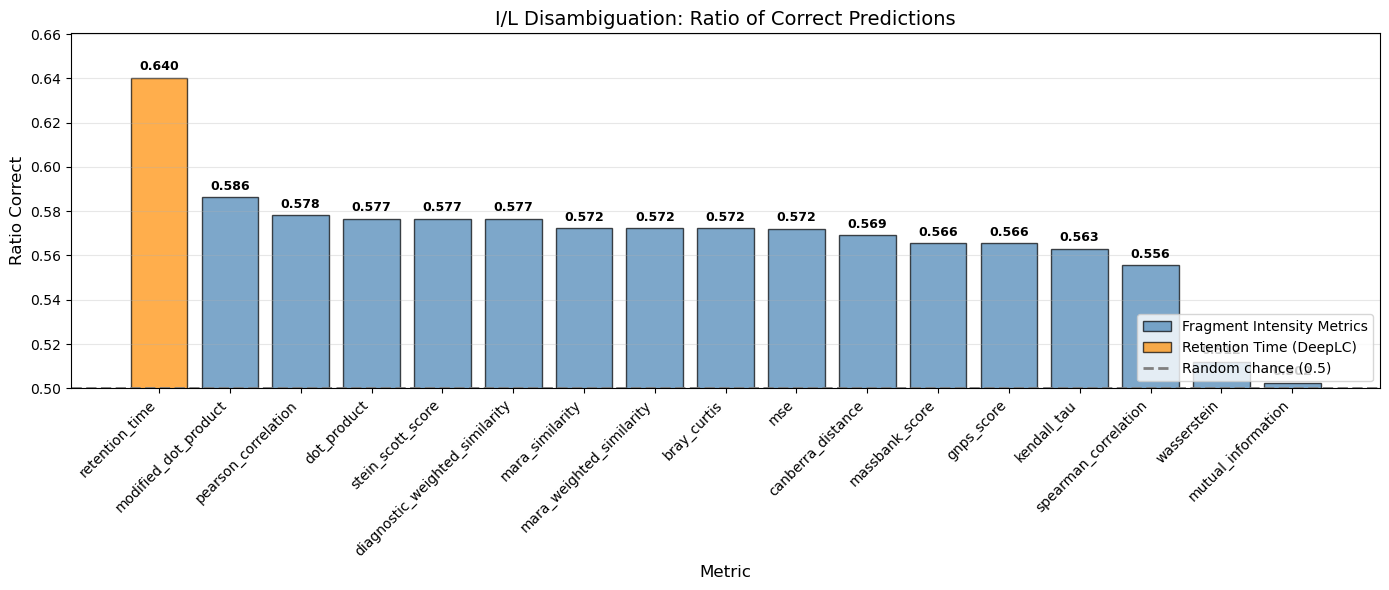


Note: CCS excluded from comparison - no observed CCS values available to calculate ratio correct.
CCS discriminative power (model predicts different values): 83.66%


In [ ]:
# Collect all results
all_ratios = ratio_correct_dict.copy()
all_ratios["retention_time"] = rt_ratio

# Sort and plot
all_sorted = sorted(all_ratios.keys(), key=lambda x: all_ratios[x], reverse=True)
all_values = [all_ratios[m] for m in all_sorted]

fig, ax = plt.subplots(figsize=(14, 6))

# Color RT differently
colors = ['darkorange' if m == 'retention_time' else 'steelblue' for m in all_sorted]
bars = ax.bar(range(len(all_sorted)), all_values, color=colors, edgecolor='black', alpha=0.7)

for bar, val in zip(bars, all_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', edgecolor='black', alpha=0.7, label='Fragment Intensity Metrics'),
    Patch(facecolor='darkorange', edgecolor='black', alpha=0.7, label='Retention Time (DeepLC)'),
    plt.Line2D([0], [0], color='gray', linestyle='--', linewidth=2, label='Random chance (0.5)')
]
ax.legend(handles=legend_elements, loc='top right')

ax.set_xticks(range(len(all_sorted)))
ax.set_xticklabels(all_sorted, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Ratio Correct', fontsize=12)
ax.set_xlabel('Metric', fontsize=12)
ax.set_title('I/L Disambiguation: Ratio of Correct Predictions', fontsize=14)
ax.set_ylim([0.5, max(all_values) + 0.02])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("../temp_data/all_metrics_ratio_correct_bargraph.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Print summary
print("I/L Disambiguation Results Summary:")
print("=" * 50)
for m, v in zip(all_sorted, all_values):
    label = "(RT)" if m == "retention_time" else ""
    print(f"{m:35s}: {v:.4f} {label}")

I/L Disambiguation Results Summary:
retention_time                     : 0.6403 (RT)
modified_dot_product               : 0.5863 
pearson_correlation                : 0.5781 
dot_product                        : 0.5766 
stein_scott_score                  : 0.5765 
diagnostic_weighted_similarity     : 0.5765 
mara_similarity                    : 0.5724 
mara_weighted_similarity           : 0.5724 
bray_curtis                        : 0.5723 
mse                                : 0.5720 
canberra_distance                  : 0.5691 
massbank_score                     : 0.5655 
gnps_score                         : 0.5655 
kendall_tau                        : 0.5630 
spearman_correlation               : 0.5556 
wasserstein                        : 0.5119 
mutual_information                 : 0.5025 


In [ ]:
# Function to find position of I/L swap and extract flanking amino acids
def get_swap_info(original_seq, swapped_seq):
    """
    Find where I/L was swapped and extract flanking amino acids.
    Returns: (swap_position, relative_position, flanking_aas)
    flanking_aas is a dict with positions -3 to +3 (excluding 0)
    """
    # Remove modifications for position analysis
    clean_orig = re.sub(r'\[.*?\]', '', original_seq)
    clean_swap = re.sub(r'\[.*?\]', '', swapped_seq)
    
    if len(clean_orig) != len(clean_swap):
        return None, None, None
    
    # Find swap position
    swap_pos = None
    for i, (a, b) in enumerate(zip(clean_orig, clean_swap)):
        if a != b:
            swap_pos = i
            break
    
    if swap_pos is None:
        return None, None, None
    
    seq_len = len(clean_orig)
    relative_pos = swap_pos / (seq_len - 1) if seq_len > 1 else 0.5  # Normalized to 0-1
    
    # Extract flanking amino acids (positions -3 to +3)
    flanking = {}
    for offset in [-3, -2, -1, 1, 2, 3]:
        idx = swap_pos + offset
        if 0 <= idx < seq_len:
            flanking[offset] = clean_orig[idx]
        else:
            flanking[offset] = None  # Out of bounds
    
    return swap_pos, relative_pos, flanking

# Get swap info for all scored peptides (fragment intensity - modified_dot_product)
swap_data_intensity = []
for seq in scored_df_seqs.index:
    swap_seq = dict_orig_to_swap.get(seq)
    if swap_seq is None:
        continue
    
    swap_pos, rel_pos, flanking = get_swap_info(seq, swap_seq)
    if swap_pos is None:
        continue
    
    # Get scores for modified_dot_product
    score_orig = scored_df_seqs.loc[seq, "modified_dot_product|orig"]
    score_swap = scored_df_seqs.loc[seq, "modified_dot_product|swapped"]
    is_correct = score_orig > score_swap  # Original should score higher
    
    swap_data_intensity.append({
        "sequence": seq,
        "swap_position": swap_pos,
        "relative_position": rel_pos,
        "is_correct": is_correct,
        "seq_length": len(re.sub(r'\[.*?\]', '', seq)),
        **{f"flank_{k}": v for k, v in flanking.items()}
    })

swap_df_intensity = pd.DataFrame(swap_data_intensity)
print(f"Fragment Intensity (modified_dot_product): {len(swap_df_intensity)} peptides")
print(f"Overall ratio correct: {swap_df_intensity['is_correct'].mean():.4f}")

Fragment Intensity (modified_dot_product): 27069 peptides
Overall ratio correct: 0.5891


In [ ]:
# Train/eval split (10% for calibration, 90% for evaluation)
df_train = merged_df.sample(frac=0.1, random_state=42)
df_eval_rt = merged_df.drop(df_train.index).copy()

# Build PSM lists
psm_list_train = PSMList(psm_list=[
    PSM(peptidoform=row["proforma_deeplc"], retention_time=row["Calibrated retention time_mean"], spectrum_id=idx)
    for idx, row in df_train.iterrows()
])

# Create swapped sequences dict for RT
rt_swap_dict = {}
for idx, row in df_eval_rt.iterrows():
    rt_swap_dict[row["proforma_deeplc"]] = switch_random_il(row["proforma_deeplc"])

psm_list_eval = PSMList(psm_list=[
    PSM(peptidoform=row["proforma_deeplc"], retention_time=row["Calibrated retention time_mean"], spectrum_id=idx)
    for idx, row in df_eval_rt.iterrows()
])
psm_list_eval_swapped = PSMList(psm_list=[
    PSM(peptidoform=rt_swap_dict[row["proforma_deeplc"]], retention_time=row["Calibrated retention time_mean"], spectrum_id=idx)
    for idx, row in df_eval_rt.iterrows()
])

# Train DeepLC and make predictions
dlc = DeepLC(deeplc_retrain=False, n_epochs=20)
dlc.calibrate_preds(psm_list_train)
preds_rt = dlc.make_preds(psm_list=psm_list_eval)
preds_rt_swapped = dlc.make_preds(psm_list=psm_list_eval_swapped)

# Add predictions to df_eval_rt
df_eval_rt["predicted_rt"] = preds_rt
df_eval_rt["predicted_rt_swapped"] = preds_rt_swapped
df_eval_rt["swapped_seq"] = [rt_swap_dict[seq] for seq in df_eval_rt["proforma_deeplc"]]

print(f"RT predictions complete: {len(df_eval_rt)} peptides")

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step
 1/39 ━━━━━━━━━━━━━━━━━━━━ 14s 385ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001EFF610FF60> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 149ms/step
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 149ms/ste

In [ ]:
# Get swap info for RT predictions
swap_data_rt = []
for idx, row in df_eval_rt.iterrows():
    orig_seq = row["proforma_deeplc"]
    swap_seq = row["swapped_seq"]
    
    # Check if has I/L
    if not has_il_outside_brackets(orig_seq):
        continue
    
    swap_pos, rel_pos, flanking = get_swap_info(orig_seq, swap_seq)
    if swap_pos is None:
        continue
    
    # Determine which prediction is correct
    obs_rt = row["Calibrated retention time_mean"]
    diff_orig = abs(row["predicted_rt"] - obs_rt)
    diff_swap = abs(row["predicted_rt_swapped"] - obs_rt)
    is_correct = diff_orig <= diff_swap
    
    swap_data_rt.append({
        "sequence": orig_seq,
        "swap_position": swap_pos,
        "relative_position": rel_pos,
        "is_correct": is_correct,
        "seq_length": len(re.sub(r'\[.*?\]', '', orig_seq)),
        **{f"flank_{k}": v for k, v in flanking.items()}
    })

swap_df_rt = pd.DataFrame(swap_data_rt)
print(f"Retention Time (DeepLC): {len(swap_df_rt)} peptides with I/L")
print(f"Overall ratio correct: {swap_df_rt['is_correct'].mean():.4f}")

Retention Time (DeepLC): 35506 peptides with I/L
Overall ratio correct: 0.6422


In [ ]:
def calculate_position_ratios(swap_df, n_bins=8):
    """Calculate ratio correct per position bin."""
    swap_df = swap_df.copy()
    swap_df["position_bin"] = pd.cut(swap_df["relative_position"], bins=n_bins, labels=False)
    
    position_ratios = []
    for bin_idx in range(n_bins):
        bin_data = swap_df[swap_df["position_bin"] == bin_idx]
        if len(bin_data) > 0:
            ratio = bin_data["is_correct"].mean()
            ratio = 1.0 - ratio if ratio < 0.5 else ratio
            position_ratios.append({
                "bin": bin_idx,
                "bin_label": f"{bin_idx/n_bins:.2f}-{(bin_idx+1)/n_bins:.2f}",
                "ratio_correct": ratio,
                "count": len(bin_data)
            })
    return pd.DataFrame(position_ratios)

n_bins = 8
position_df_intensity = calculate_position_ratios(swap_df_intensity, n_bins)
position_df_rt = calculate_position_ratios(swap_df_rt, n_bins)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Modified Dot Product
ax1 = axes[0]
bars1 = ax1.bar(position_df_intensity["bin_label"], position_df_intensity["ratio_correct"], 
                color='steelblue', edgecolor='black', alpha=0.7)
for bar, count in zip(bars1, position_df_intensity["count"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'n={count}', ha='center', va='bottom', fontsize=8)
ax1.axhline(y=0.5, color='gray', linestyle='--', linewidth=2, label='Random chance')
ax1.set_xlabel('Relative Position of I/L Swap (N-term → C-term)', fontsize=11)
ax1.set_ylabel('Ratio Correct', fontsize=11)
ax1.set_title('Fragment Intensity (modified_dot_product)', fontsize=12, fontweight='bold')
ax1.set_ylim([0.45, max(position_df_intensity["ratio_correct"]) + 0.05])
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3, axis='y')
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Retention Time
ax2 = axes[1]
bars2 = ax2.bar(position_df_rt["bin_label"], position_df_rt["ratio_correct"], 
                color='darkorange', edgecolor='black', alpha=0.7)
for bar, count in zip(bars2, position_df_rt["count"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             f'n={count}', ha='center', va='bottom', fontsize=8)
ax2.axhline(y=0.5, color='gray', linestyle='--', linewidth=2, label='Random chance')
ax2.set_xlabel('Relative Position of I/L Swap (N-term → C-term)', fontsize=11)
ax2.set_ylabel('Ratio Correct', fontsize=11)
ax2.set_title('Retention Time (DeepLC)', fontsize=12, fontweight='bold')
ax2.set_ylim([0.45, max(position_df_rt["ratio_correct"]) + 0.05])
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("../temp_data/figure4a_position_ratio_both.png", dpi=300, bbox_inches='tight')
plt.show()

print("\nFragment Intensity - Ratio correct by position bin:")
print(position_df_intensity.to_string(index=False))
print("\nRetention Time - Ratio correct by position bin:")
print(position_df_rt.to_string(index=False))


Fragment Intensity - Ratio correct by position bin:
 bin bin_label  ratio_correct  count
   0 0.00-0.12       0.679193   2528
   1 0.12-0.25       0.722733   2503
   2 0.25-0.38       0.686455   2931
   3 0.38-0.50       0.625828   3926
   4 0.50-0.62       0.567871   3293
   5 0.62-0.75       0.532172   4476
   6 0.75-0.88       0.508783   4554
   7 0.88-1.00       0.516095   2858

Retention Time - Ratio correct by position bin:
 bin bin_label  ratio_correct  count
   0 0.00-0.12       0.690183   3005
   1 0.12-0.25       0.658852   3327
   2 0.25-0.38       0.642522   3838
   3 0.38-0.50       0.640445   5123
   4 0.50-0.62       0.634051   4364
   5 0.62-0.75       0.639481   5775
   6 0.75-0.88       0.626552   6041
   7 0.88-1.00       0.630548   4033


In [ ]:
# Standard amino acids
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")
positions = [-3, -2, -1, 1, 2, 3]
position_labels = ["-3", "-2", "-1", "+1", "+2", "+3"]

def calculate_flanking_heatmap(swap_df, min_count=10):
    """Calculate 20x6 heatmap data for flanking amino acids."""
    # Shape: rows = amino acids (20), columns = positions (6)
    heatmap_data = np.zeros((len(amino_acids), len(positions)))
    count_data = np.zeros((len(amino_acids), len(positions)))
    
    for j, pos in enumerate(positions):
        col_name = f"flank_{pos}"
        for i, aa in enumerate(amino_acids):
            mask = swap_df[col_name] == aa
            subset = swap_df[mask]
            
            if len(subset) >= min_count:
                ratio = subset["is_correct"].mean()
                ratio = 1.0 - ratio if ratio < 0.5 else ratio
                heatmap_data[i, j] = ratio
                count_data[i, j] = len(subset)
            else:
                heatmap_data[i, j] = np.nan
                count_data[i, j] = len(subset) if len(subset) > 0 else 0
    
    return heatmap_data, count_data

# Calculate heatmaps for both metrics
heatmap_intensity, count_intensity = calculate_flanking_heatmap(swap_df_intensity)
heatmap_rt, count_rt = calculate_flanking_heatmap(swap_df_rt)

# Calculate average ratio per amino acid (ignoring NaN values)
avg_ratio_intensity = np.nanmean(heatmap_intensity, axis=1)
avg_ratio_rt = np.nanmean(heatmap_rt, axis=1)

# Sort amino acids by average ratio (descending) - using intensity for ordering
sort_idx_intensity = np.argsort(avg_ratio_intensity)[::-1]
sort_idx_rt = np.argsort(avg_ratio_rt)[::-1]

# Reorder heatmaps and amino acid labels
heatmap_intensity_sorted = heatmap_intensity[sort_idx_intensity, :]
count_intensity_sorted = count_intensity[sort_idx_intensity, :]
aa_sorted_intensity = [amino_acids[i] for i in sort_idx_intensity]

heatmap_rt_sorted = heatmap_rt[sort_idx_rt, :]
count_rt_sorted = count_rt[sort_idx_rt, :]
aa_sorted_rt = [amino_acids[i] for i in sort_idx_rt]

# Create side-by-side heatmaps (20 rows x 6 columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 12))

# Use a single color gradient (sequential colormap)
cmap = sns.color_palette("Blues", as_cmap=True)

# Heatmap 1: Modified Dot Product (sorted by its own average)
ax1 = axes[0]
im1 = ax1.imshow(heatmap_intensity_sorted, cmap=cmap, aspect='auto', vmin=0.45, vmax=0.70)
cbar1 = plt.colorbar(im1, ax=ax1, label='Ratio Correct', shrink=0.8)

ax1.set_xticks(range(len(positions)))
ax1.set_xticklabels(position_labels, fontsize=11)
ax1.set_yticks(range(len(amino_acids)))
ax1.set_yticklabels(aa_sorted_intensity, fontsize=10)
ax1.set_xlabel('Position Relative to I/L Swap', fontsize=12)
ax1.set_ylabel('Flanking Amino Acid (sorted by avg ratio)', fontsize=12)
ax1.set_title('Fragment Intensity\n(modified_dot_product)', fontsize=12, fontweight='bold')

# Add value annotations
for i in range(len(amino_acids)):
    for j in range(len(positions)):
        if not np.isnan(heatmap_intensity_sorted[i, j]):
            val = heatmap_intensity_sorted[i, j]
            color = 'white' if val > 0.60 else 'black'
            ax1.text(j, i, f'{val:.2f}', ha='center', va='center', 
                    fontsize=7, color=color, fontweight='bold')

# Heatmap 2: Retention Time (sorted by its own average)
ax2 = axes[1]
im2 = ax2.imshow(heatmap_rt_sorted, cmap=cmap, aspect='auto', vmin=0.45, vmax=0.70)
cbar2 = plt.colorbar(im2, ax=ax2, label='Ratio Correct', shrink=0.8)

ax2.set_xticks(range(len(positions)))
ax2.set_xticklabels(position_labels, fontsize=11)
ax2.set_yticks(range(len(amino_acids)))
ax2.set_yticklabels(aa_sorted_rt, fontsize=10)
ax2.set_xlabel('Position Relative to I/L Swap', fontsize=12)
ax2.set_ylabel('Flanking Amino Acid (sorted by avg ratio)', fontsize=12)
ax2.set_title('Retention Time\n(DeepLC)', fontsize=12, fontweight='bold')

# Add value annotations
for i in range(len(amino_acids)):
    for j in range(len(positions)):
        if not np.isnan(heatmap_rt_sorted[i, j]):
            val = heatmap_rt_sorted[i, j]
            color = 'white' if val > 0.60 else 'black'
            ax2.text(j, i, f'{val:.2f}', ha='center', va='center', 
                    fontsize=7, color=color, fontweight='bold')

plt.tight_layout()
plt.savefig("../temp_data/figure4b_flanking_heatmap_both.png", dpi=300, bbox_inches='tight')
plt.show()


Amino Acid Ranking by Average Ratio Correct

Fragment Intensity (modified_dot_product):
   1. R: 0.6511
   2. Q: 0.6214
   3. T: 0.6172
   4. S: 0.6134
   5. G: 0.6089
   6. E: 0.6074
   7. Y: 0.6072
   8. V: 0.6054
   9. A: 0.6034
  10. N: 0.6018
  11. D: 0.6012
  12. F: 0.5960
  13. L: 0.5930
  14. W: 0.5895
  15. I: 0.5887
  16. M: 0.5785
  17. P: 0.5725
  18. H: 0.5595
  19. C: 0.5575
  20. K: 0.5553

Retention Time (DeepLC):
   1. D: 0.6709
   2. Y: 0.6609
   3. E: 0.6548
   4. Q: 0.6541
   5. T: 0.6530
   6. S: 0.6468
   7. W: 0.6467
   8. N: 0.6459
   9. C: 0.6458
  10. G: 0.6422
  11. V: 0.6421
  12. A: 0.6400
  13. L: 0.6296
  14. F: 0.6295
  15. P: 0.6294
  16. R: 0.6290
  17. M: 0.6206
  18. I: 0.6125
  19. K: 0.5986
  20. H: 0.5857


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 12))

# Count Heatmap 1: Fragment Intensity
ax1 = axes[0]
log_counts1 = np.log10(count_intensity + 1)
im1 = ax1.imshow(log_counts1, cmap='YlOrRd', aspect='auto')
cbar1 = plt.colorbar(im1, ax=ax1, label='log10(Count + 1)', shrink=0.8)

ax1.set_xticks(range(len(positions)))
ax1.set_xticklabels(position_labels, fontsize=11)
ax1.set_yticks(range(len(amino_acids)))
ax1.set_yticklabels(amino_acids, fontsize=10)
ax1.set_xlabel('Position Relative to I/L Swap', fontsize=12)
ax1.set_ylabel('Flanking Amino Acid', fontsize=12)
ax1.set_title('Sample Counts - Fragment Intensity', fontsize=12, fontweight='bold')

for i in range(len(amino_acids)):
    for j in range(len(positions)):
        count = int(count_intensity[i, j])
        if count > 0:
            color = 'white' if log_counts1[i, j] > 2.5 else 'black'
            ax1.text(j, i, f'{count}', ha='center', va='center', fontsize=6, color=color)

# Count Heatmap 2: Retention Time
ax2 = axes[1]
log_counts2 = np.log10(count_rt + 1)
im2 = ax2.imshow(log_counts2, cmap='YlOrRd', aspect='auto')
cbar2 = plt.colorbar(im2, ax=ax2, label='log10(Count + 1)', shrink=0.8)

ax2.set_xticks(range(len(positions)))
ax2.set_xticklabels(position_labels, fontsize=11)
ax2.set_yticks(range(len(amino_acids)))
ax2.set_yticklabels(amino_acids, fontsize=10)
ax2.set_xlabel('Position Relative to I/L Swap', fontsize=12)
ax2.set_ylabel('Flanking Amino Acid', fontsize=12)
ax2.set_title('Sample Counts - Retention Time', fontsize=12, fontweight='bold')

for i in range(len(amino_acids)):
    for j in range(len(positions)):
        count = int(count_rt[i, j])
        if count > 0:
            color = 'white' if log_counts2[i, j] > 2.5 else 'black'
            ax2.text(j, i, f'{count}', ha='center', va='center', fontsize=6, color=color)

plt.tight_layout()
plt.savefig("../temp_data/figure4c_flanking_counts_both.png", dpi=300, bbox_inches='tight')
plt.show()